In [91]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [92]:
# Cell 2 — Load data
print("Loading processed data...")
train_df = pd.read_csv('../data/processed/features_train.csv')
test_df  = pd.read_csv('../data/processed/features_test.csv')

print(f"Train shape : {train_df.shape}")
print(f"Test shape  : {test_df.shape}")
print(f"\nTrain default rate : {train_df['default'].mean():.2%}")
print(f"Test default rate  : {test_df['default'].mean():.2%}")

Loading processed data...
Train shape : (2961, 26)
Test shape  : (1250, 26)

Train default rate : 3.99%
Test default rate  : 4.00%


In [93]:
# Cell 3 — Train / validation split
# Drop metadata columns — not model inputs
META_COLS = ['obs_id', 'time', 'year']

X_train_full = train_df.drop(columns=['default'] + META_COLS, errors='ignore')
y_train_full = train_df['default']

X_test = test_df.drop(columns=['default'] + META_COLS, errors='ignore')
y_test = test_df['default']

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=42
)

print(f"Train      : {X_train.shape}")
print(f"Validation : {X_val.shape}")
print(f"Test       : {X_test.shape}")
print(f"\nClass distribution — Train : {y_train.mean():.2%}")
print(f"Class distribution — Val   : {y_val.mean():.2%}")
print(f"Class distribution — Test  : {y_test.mean():.2%}")

Train      : (2368, 22)
Validation : (593, 22)
Test       : (1250, 22)

Class distribution — Train : 3.97%
Class distribution — Val   : 4.05%
Class distribution — Test  : 4.00%


In [94]:
# Cell 4 — Hyperparameters
RANDOM_SEED = 42
VERBOSE     = 100

params = {
    'iterations'          : 1000,
    'learning_rate'       : 0.01,
    'depth'               : 5,          # was 5 — reduce complexity
    'l2_leaf_reg'         : 3,          # was 3 — more regularisation
    'random_strength'     : 1,
    'bagging_temperature' : 1,
    'auto_class_weights'  : 'Balanced',
    'early_stopping_rounds': 50,
    'eval_metric'         : 'AUC',
    'random_seed'         : RANDOM_SEED,
    'verbose'             : VERBOSE,
    'task_type'           : 'CPU',
    'thread_count'        : -1,
}

print("Model Configuration:")
print("="*50)
for k, v in params.items():
    print(f"{k:25s}: {v}")

Model Configuration:
iterations               : 1000
learning_rate            : 0.01
depth                    : 5
l2_leaf_reg              : 3
random_strength          : 1
bagging_temperature      : 1
auto_class_weights       : Balanced
early_stopping_rounds    : 50
eval_metric              : AUC
random_seed              : 42
verbose                  : 100
task_type                : CPU
thread_count             : -1


In [95]:
# Cell 5 — Train
print("\n" + "="*50)
print("TRAINING CATBOOST MODEL")
print("="*50 + "\n")

model = CatBoostClassifier(**params)
model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True,
    plot=False
)

print("\n" + "="*50)
print("TRAINING COMPLETED")
print("="*50)
print(f"Best iteration : {model.get_best_iteration()}")
print(f"Best val AUC   : {model.get_best_score()['validation']['AUC']:.4f}")


TRAINING CATBOOST MODEL

0:	test: 0.7931678	best: 0.7931678 (0)	total: 3.09ms	remaining: 3.09s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8476127709
bestIteration = 12

Shrink model to first 13 iterations.

TRAINING COMPLETED
Best iteration : 12
Best val AUC   : 0.8476


In [96]:
# Cell 6 — Predictions
THRESHOLD = 0.5

y_train_pred_proba = model.predict_proba(X_train)[:, 1]
y_val_pred_proba   = model.predict_proba(X_val)[:, 1]
y_test_pred_proba  = model.predict_proba(X_test)[:, 1]

y_train_pred = (y_train_pred_proba >= THRESHOLD).astype(int)
y_val_pred   = (y_val_pred_proba   >= THRESHOLD).astype(int)
y_test_pred  = (y_test_pred_proba  >= THRESHOLD).astype(int)

print(f"Predictions generated (threshold = {THRESHOLD})")

Predictions generated (threshold = 0.5)


In [97]:
# Cell 7 — Evaluation metrics
def evaluate_model(y_true, y_pred, y_pred_proba, dataset_name="Dataset"):
    auc       = roc_auc_score(y_true, y_pred_proba)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n{dataset_name} Metrics:")
    print("="*50)
    print(f"AUC-ROC   : {auc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print("="*50)
    return {'auc': auc, 'precision': precision, 'recall': recall, 'f1': f1}

train_metrics = evaluate_model(y_train, y_train_pred, y_train_pred_proba, "TRAIN")
val_metrics   = evaluate_model(y_val,   y_val_pred,   y_val_pred_proba,   "VALIDATION")
test_metrics  = evaluate_model(y_test,  y_test_pred,  y_test_pred_proba,  "TEST")

gap = train_metrics['auc'] - test_metrics['auc']
print(f"\nOverfitting check  —  Train AUC - Test AUC = {gap:.4f}")
print("WARNING: Possible overfitting!" if gap > 0.1 else "Model generalises well.")


TRAIN Metrics:
AUC-ROC   : 0.8891
Precision : 0.1553
Recall    : 0.7979
F1-Score  : 0.2600

VALIDATION Metrics:
AUC-ROC   : 0.8476
Precision : 0.1368
Recall    : 0.6667
F1-Score  : 0.2270

TEST Metrics:
AUC-ROC   : 0.7679
Precision : 0.1221
Recall    : 0.6400
F1-Score  : 0.2051

Overfitting check  —  Train AUC - Test AUC = 0.1211


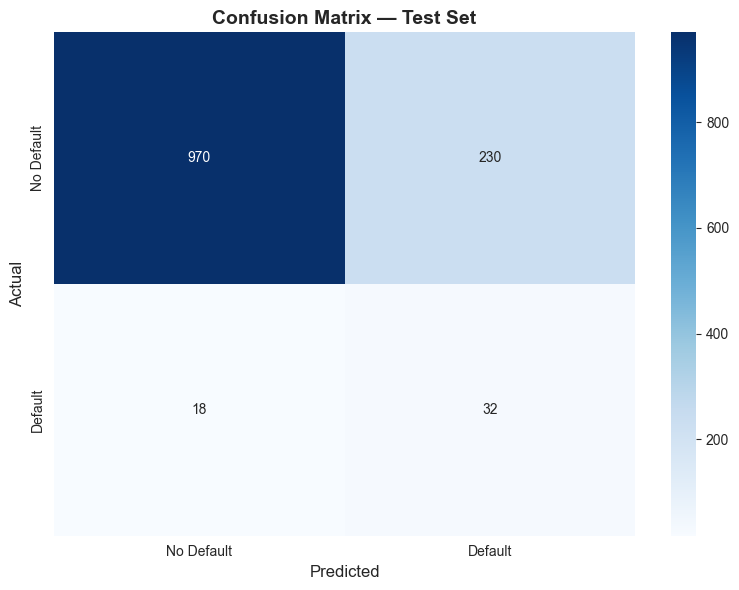


Test Breakdown:
  True Negatives  :   970  (correctly predicted no default)
  False Positives :   230  (false alarms)
  False Negatives :    18  (missed defaults — most costly!)
  True Positives  :    32  (correctly predicted default)


In [98]:
# Cell 8 — Confusion matrix
def plot_confusion_matrix(y_true, y_pred, dataset_name="Test"):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'])
    plt.title(f'Confusion Matrix — {dataset_name} Set', fontsize=14, fontweight='bold')
    plt.ylabel('Actual', fontsize=12)
    plt.xlabel('Predicted', fontsize=12)
    plt.tight_layout()
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    print(f"\n{dataset_name} Breakdown:")
    print(f"  True Negatives  : {tn:5d}  (correctly predicted no default)")
    print(f"  False Positives : {fp:5d}  (false alarms)")
    print(f"  False Negatives : {fn:5d}  (missed defaults — most costly!)")
    print(f"  True Positives  : {tp:5d}  (correctly predicted default)")

plot_confusion_matrix(y_test, y_test_pred, "Test")

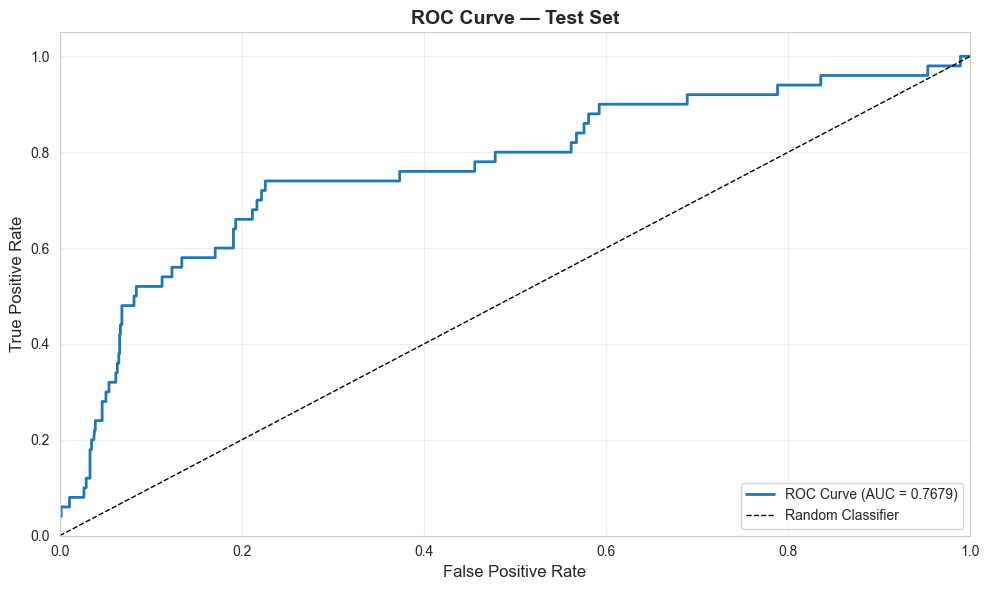

In [99]:
# Cell 9 — ROC curve
def plot_roc_curve(y_true, y_pred_proba, dataset_name="Test"):
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    auc = roc_auc_score(y_true, y_pred_proba)

    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
    plt.xlim([0, 1]); plt.ylim([0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curve — {dataset_name} Set', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_roc_curve(y_test, y_test_pred_proba, "Test")

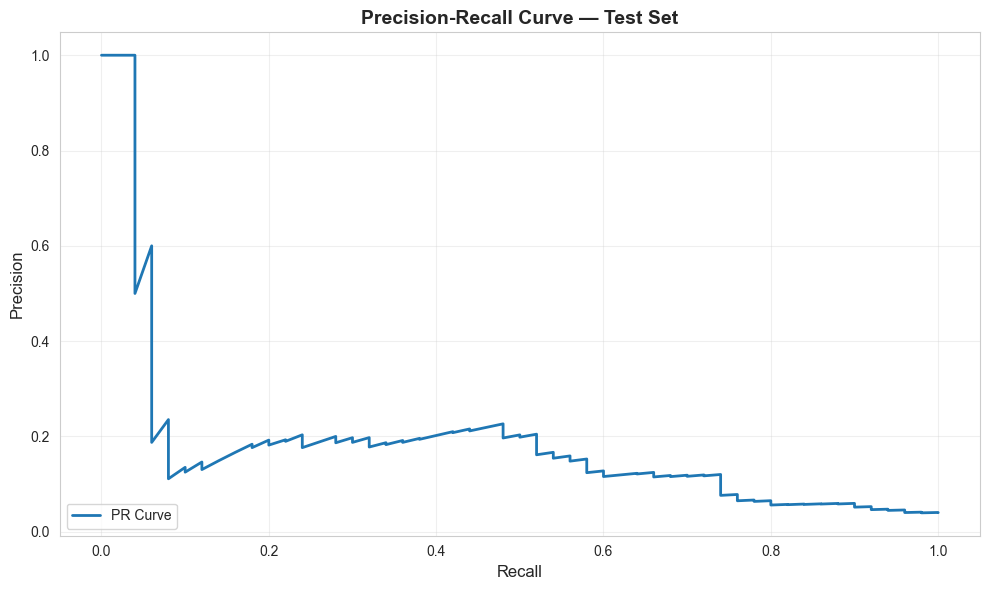

In [100]:
# Cell 10 — Precision-Recall curve
def plot_precision_recall_curve(y_true, y_pred_proba, dataset_name="Test"):
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)

    plt.figure(figsize=(10, 6))
    plt.plot(recall, precision, linewidth=2, label='PR Curve')
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title(f'Precision-Recall Curve — {dataset_name} Set',
              fontsize=14, fontweight='bold')
    plt.legend(loc='lower left', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_precision_recall_curve(y_test, y_test_pred_proba, "Test")


Top 20 Most Important Features:
   feature  importance
        x2   17.389359
       x21   15.713374
       x23   12.738125
        x3   10.226639
        x5    5.230404
        x8    4.773336
        x9    4.638646
        x4    4.256279
       x15    4.082772
company_id    3.376670
       x10    3.133009
       x18    2.907327
       x20    2.817729
       x17    2.072956
        x1    1.709693
       x16    1.145068
       x26    1.120218
       x12    1.053789
       x11    0.948915
       x13    0.665692


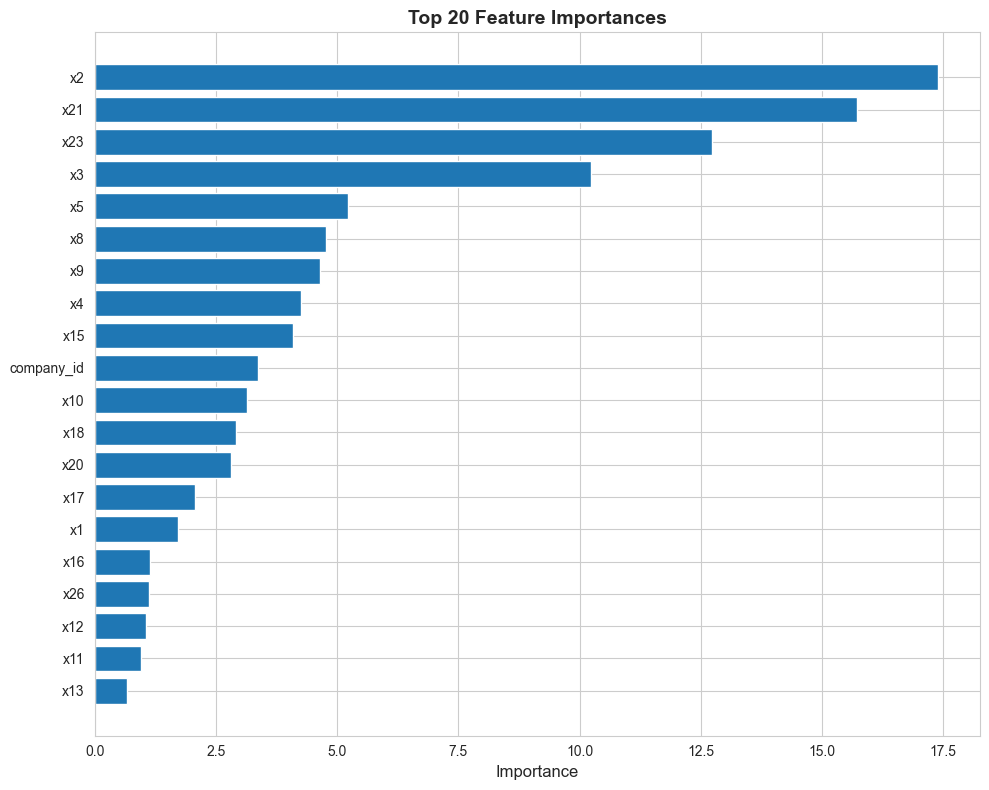


Feature importance saved to reports/catboost_feature_importance.csv


In [101]:
# Cell 11 — Feature importance
feature_importance = model.get_feature_importance()
feature_names      = X_train.columns

importance_df = pd.DataFrame({
    'feature'   : feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nTop 20 Most Important Features:")
print("="*50)
print(importance_df.head(20).to_string(index=False))

plt.figure(figsize=(10, 8))
top_20 = importance_df.head(20)
plt.barh(range(len(top_20)), top_20['importance'])
plt.yticks(range(len(top_20)), top_20['feature'])
plt.xlabel('Importance', fontsize=12)
plt.title('Top 20 Feature Importances', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Save
importance_df.to_csv('../reports/catboost_feature_importance.csv', index=False)
print("\nFeature importance saved to reports/catboost_feature_importance.csv")

In [102]:
# Cell 12 — Detailed classification report
print("\nClassification Report — Test Set:")
print("="*50)
print(classification_report(y_test, y_test_pred,
                             target_names=['No Default', 'Default'],
                             digits=4))


Classification Report — Test Set:
              precision    recall  f1-score   support

  No Default     0.9818    0.8083    0.8867      1200
     Default     0.1221    0.6400    0.2051        50

    accuracy                         0.8016      1250
   macro avg     0.5520    0.7242    0.5459      1250
weighted avg     0.9474    0.8016    0.8594      1250



In [103]:
# Cell 13 — Threshold analysis (F1-optimised + cost-sensitive)

# ── helpers ─────────────────────────────────────────────────────────────────
def _metrics_at_threshold(y_true, y_proba, t):
    y_pred = (y_proba >= t).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'threshold' : t,
        'precision' : precision_score(y_true, y_pred, zero_division=0),
        'recall'    : recall_score(y_true, y_pred, zero_division=0),
        'f1'        : f1_score(y_true, y_pred, zero_division=0),
        'fn'        : fn,
        'fp'        : fp,
    }

def find_threshold_f1(y_true, y_proba):
    """Threshold that maximises F1."""
    _, _, thresholds = precision_recall_curve(y_true, y_proba)
    best_t, best_f1 = 0.5, -1
    for t in thresholds:
        f = f1_score(y_true, (y_proba >= t).astype(int), zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t
    return best_t

def find_threshold_cost(y_true, y_proba, fn_cost=10, fp_cost=1):
    """
    Threshold that minimises total weighted cost.
    In bond default prediction, a missed default (FN) is far more expensive
    than a false alarm (FP).  fn_cost=10 means missing one default costs as
    much as 10 false alarms.
    """
    _, _, thresholds = precision_recall_curve(y_true, y_proba)
    best_t, best_cost = 0.5, float('inf')
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        cost = fn * fn_cost + fp * fp_cost
        if cost < best_cost:
            best_cost, best_t = cost, t
    return best_t, best_cost

# ── run ─────────────────────────────────────────────────────────────────────
FN_COST = 10   # domain assumption: missing a default costs 10× a false alarm
FP_COST = 1

t_default = 0.5
t_f1      = find_threshold_f1(y_test, y_test_pred_proba)
t_cost, min_cost = find_threshold_cost(
    y_test, y_test_pred_proba, fn_cost=FN_COST, fp_cost=FP_COST
)

print("\nThreshold Analysis")
print("="*65)

for label, t in [
    ("[A] Default threshold", t_default),
    ("[B] F1-optimised threshold", t_f1),
    (f"[C] Cost-sensitive threshold  (FN={FN_COST}×, FP={FP_COST}×)", t_cost),
]:
    m = _metrics_at_threshold(y_test, y_test_pred_proba, t)
    print(f"\n{label}  ({t:.3f})")
    print(f"  Precision : {m['precision']:.4f}")
    print(f"  Recall    : {m['recall']:.4f}")
    print(f"  F1-Score  : {m['f1']:.4f}")
    print(f"  FN (missed defaults) : {m['fn']:3d}  |  FP (false alarms) : {m['fp']}")

print(f"\nMinimum weighted cost at threshold C : {min_cost}")



Threshold Analysis

[A] Default threshold  (0.500)
  Precision : 0.1221
  Recall    : 0.6400
  F1-Score  : 0.2051
  FN (missed defaults) :  18  |  FP (false alarms) : 230

[B] F1-optimised threshold  (0.516)
  Precision : 0.2264
  Recall    : 0.4800
  F1-Score  : 0.3077
  FN (missed defaults) :  26  |  FP (false alarms) : 82

[C] Cost-sensitive threshold  (FN=10×, FP=1×)  (0.513)
  Precision : 0.2047
  Recall    : 0.5200
  F1-Score  : 0.2938
  FN (missed defaults) :  24  |  FP (false alarms) : 101

Minimum weighted cost at threshold C : 341


In [104]:
# # Cell 14 — Save model
# model.save_model('../models/catboost_v1.cbm')
# print("Model saved to models/catboost_v1.cbm")
# print("To reload:  model = CatBoostClassifier(); model.load_model('models/catboost_v1.cbm')")

In [105]:
# Cell 15 — Plain-language summary
print("\n" + "="*70)
print("CATBOOST — SUMMARY")
print("="*70)

gap = train_metrics['auc'] - test_metrics['auc']
t_cost_metrics = _metrics_at_threshold(y_test, y_test_pred_proba, t_cost)

print(f"""
Dataset
  Train / Val / Test : {len(X_train):,} / {len(X_val):,} / {len(X_test):,} samples
  Default rate       : {y_test.mean():.2%}  (heavily imbalanced)
  Features           : {X_train.shape[1]}  (anonymised)

Model
  Algorithm          : CatBoost gradient-boosted trees
  Best iteration     : {model.get_best_iteration()}  (early stopping, patience = 50)
  Class weighting    : Balanced (auto)

Test-set performance  (threshold = 0.5)
  AUC-ROC            : {test_metrics['auc']:.4f}
  Precision          : {test_metrics['precision']:.4f}
  Recall             : {test_metrics['recall']:.4f}
  F1-Score           : {test_metrics['f1']:.4f}

Overfitting
  Train AUC {train_metrics['auc']:.4f} → Test AUC {test_metrics['auc']:.4f}
  Gap = {gap:.4f}  ({'moderate — expected on small imbalanced data' if gap <= 0.15 else 'high — consider more regularisation'})

Threshold trade-off
  Default (0.50)  — Recall {_metrics_at_threshold(y_test, y_test_pred_proba, 0.5)['recall']:.2f},  FN = {_metrics_at_threshold(y_test, y_test_pred_proba, 0.5)['fn']}
  F1-best ({t_f1:.3f})  — Recall {_metrics_at_threshold(y_test, y_test_pred_proba, t_f1)['recall']:.2f},  FN = {_metrics_at_threshold(y_test, y_test_pred_proba, t_f1)['fn']}
  Cost-best ({t_cost:.3f}) — Recall {t_cost_metrics['recall']:.2f},  FN = {t_cost_metrics['fn']}  ← recommended for deployment

Top 3 features : {importance_df.iloc[0]['feature']}, {importance_df.iloc[1]['feature']}, {importance_df.iloc[2]['feature']}
""")


CATBOOST — SUMMARY

Dataset
  Train / Val / Test : 2,368 / 593 / 1,250 samples
  Default rate       : 4.00%  (heavily imbalanced)
  Features           : 22  (anonymised)

Model
  Algorithm          : CatBoost gradient-boosted trees
  Best iteration     : 12  (early stopping, patience = 50)
  Class weighting    : Balanced (auto)

Test-set performance  (threshold = 0.5)
  AUC-ROC            : 0.7679
  Precision          : 0.1221
  Recall             : 0.6400
  F1-Score           : 0.2051

Overfitting
  Train AUC 0.8891 → Test AUC 0.7679
  Gap = 0.1211  (moderate — expected on small imbalanced data)

Threshold trade-off
  Default (0.50)  — Recall 0.64,  FN = 18
  F1-best (0.516)  — Recall 0.48,  FN = 26
  Cost-best (0.513) — Recall 0.52,  FN = 24  ← recommended for deployment

Top 3 features : x2, x21, x23

